## Reading in the raw file format (OBF, .sec)

In [1]:
pip install msr-reader

Note: you may need to restart the kernel to use updated packages.


In [2]:
from msr_reader import OBFFile
import glob
import tifffile as tf
import numpy as np
import cv2

img_folder = "test_images"
sec_files = glob.glob("{dir}/*.sec".format(dir=img_folder))
sec_file = sec_files[0]


def normalized_float2int8(img):
    return (255 * (img - img.min()) / (np.ptp(img) + 1e-8)).astype(np.uint8)


def laplacian_var(img):
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    return laplacian.var()


def sharpness(img):
    sharpness_vals = []
    for i in range(img.shape[0]):
        z_img = img[i]
        if z_img.dtype != np.uint8:
            z_img = normalized_float2int8(z_img)
        lap_var = laplacian_var(z_img)
        sharpness_vals.append(lap_var)
    return sum(sharpness_vals) / len(sharpness_vals)


with OBFFile(sec_file) as f:
    max_sharpness = 0
    max_sharpness_idx = 0

    # reading image data
    for idx in range(f.num_stacks):
        img = f.read_stack(idx)  # read stack with index idx into numpy array

        # Sharpness
        img_sharpness = sharpness(img)
        if img_sharpness > max_sharpness:
            max_sharpness = img_sharpness
            max_sharpness_idx = idx

        # metadata
        stack_shapes = f.shapes  # list of stack shapes, including stack and dimension names
        # like shapes, but with pixel sizes (unit: meters)
        pixel_sizes = f.pixel_sizes
        print(stack_shapes)
        print(pixel_sizes)

    # write sharpest image
    sharpest_stack = f.read_stack(max_sharpness_idx)
    tf.imwrite(
        f"{img_folder}/out/2023-10-27_m157_yxz_100x_biocytin_ATTO647N_orig.tif", sharpest_stack)
    stacks_metadata = {'pixel_sizes': [
        f.pixel_sizes[max_sharpness_idx]], 'stack_shapes': [f.shapes[max_sharpness_idx]]}

[StackSizes(name='conf_640_Cy5 {0}', sizes=[17, 520, 1630], dimension_names=['ExpControl Z', 'ExpControl X', 'ExpControl Y']), StackSizes(name='STED_640_775_Cy5 {0}', sizes=[17, 520, 1630], dimension_names=['ExpControl Z', 'ExpControl X', 'ExpControl Y'])]
[StackSizes(name='conf_640_Cy5 {0}', sizes=[3.000000106112566e-07, 2.000000012440768e-08, 2.000000052142637e-08], dimension_names=['ExpControl Z', 'ExpControl X', 'ExpControl Y']), StackSizes(name='STED_640_775_Cy5 {0}', sizes=[3.000000106112566e-07, 2.000000012440768e-08, 2.000000052142637e-08], dimension_names=['ExpControl Z', 'ExpControl X', 'ExpControl Y'])]
[StackSizes(name='conf_640_Cy5 {0}', sizes=[17, 520, 1630], dimension_names=['ExpControl Z', 'ExpControl X', 'ExpControl Y']), StackSizes(name='STED_640_775_Cy5 {0}', sizes=[17, 520, 1630], dimension_names=['ExpControl Z', 'ExpControl X', 'ExpControl Y'])]
[StackSizes(name='conf_640_Cy5 {0}', sizes=[3.000000106112566e-07, 2.000000012440768e-08, 2.000000052142637e-08], dimensi

## Reading in the masks (.mat)

In [3]:
import flammkuchen as fl

mat_files = glob.glob("{dir}/*.mat".format(dir=img_folder))
print(mat_files)
masks = list()

for mat_file in mat_files:
    masks.append(fl.load(mat_file))

['test_images/2023-10-27_m157_yxz_100x_biocytin_ATTO647N_pyramidal_cell_soma_stack_sted0.05_0.01_conf0.18_0.1deconv_mask_2023-11-30_01_42-turtles.mat', 'test_images/2023-10-27_m157_yxz_100x_biocytin_ATTO647N_pyramidal_cell_soma_stack_sted0.05_0.01_conf0.18_0.1deconv_mask_2023-11-30_01_42-mice.mat']


In [4]:
for i, m in enumerate(masks):
    print(f"Item {i}: type = {type(m)}")
    print("Keys:", list(m.keys()))
    for k, v in m.items():
        print(f"  {k}: type = {type(v)}, shape = {getattr(v, 'shape', 'N/A')}")

# Each mask element has:
# - #refs#
# - mask
# Each of those has a type and a shape:
# - #refs#: type dictionary, no shape
# - mask: type numpy array, shape (rows, cols)

Item 0: type = <class 'dict'>
Keys: ['#refs#', 'mask']
  #refs#: type = <class 'dict'>, shape = N/A
  mask: type = <class 'numpy.ndarray'>, shape = (36, 1)
Item 1: type = <class 'dict'>
Keys: ['#refs#', 'mask']
  #refs#: type = <class 'dict'>, shape = N/A
  mask: type = <class 'numpy.ndarray'>, shape = (36, 1)


### Plotting the relevant ones

In [5]:
import matplotlib.pyplot as plt
import numpy as np

mask = masks[0]['mask']
print(mask.shape)
# mask has shape (36, 1), meaning that it has 36 rows of 1 element each

# We want to overlay all the masks in a same stack. We start with the very first mask, and
# put the rest on top of it with different values (i.e. binary masks converted from 0/1 to 0/idx)
idx = 0
stack = np.zeros(mask[0][0].shape, dtype=np.uint8)

# Iterate in rows
for i in range(mask.shape[0]):
    # print(mask[i][0].shape)
    # The shape should be (17, 520, 1630), meaning that it's a 17x520x1630 (OZxOYxOX) 3D binary mask
    if len(mask[i][0].shape) == 3:
        # plt.figure()
        # plt.imshow(mask[i][0].max(0))
        # plt.colorbar()
        idx += 1
        # Put mask into stack with 'idx' where originally there were 1
        stack[mask[i][0] > 0] = idx

(36, 1)


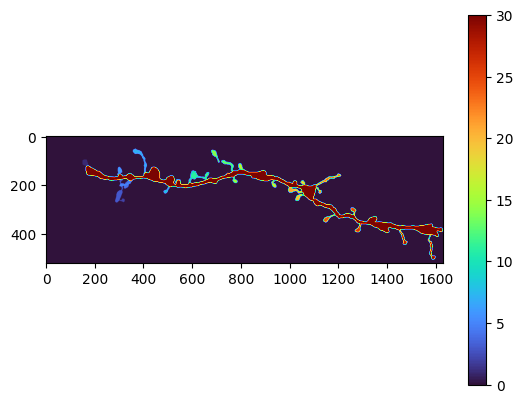

In [6]:
plt.imshow(stack.max(0), cmap='turbo')
plt.colorbar()

### Saving a stack as tif file

In [7]:
import tifffile as tf
tf.imwrite(
    f"{img_folder}/out/2023-10-27_m157_yxz_100x_biocytin_ATTO647N_stack.tif", stack)

## Semantic segmentation

Mask 30 is most likely the dendrite, with 42542 active pixels


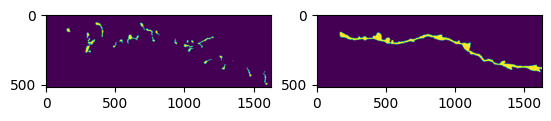

In [8]:
max_pixel_count = 0
dendrite_idx = stack.max()
# Find dendrite mask, ignore background
i = 1
while i <= mask.shape[0]:
    pixel_count = np.sum(stack == i)
    if pixel_count > max_pixel_count:
        max_pixel_count = pixel_count
        dendrite_idx = i
    i += 1
print(f"Mask {dendrite_idx} is most likely the dendrite, with {max_pixel_count} active pixels")

spines = ((stack > 0) & (stack != dendrite_idx)).astype(np.uint8) * 255
dendrite = (stack == dendrite_idx).astype(np.uint8) * 255

plt.subplot(121)
plt.imshow(spines.max(0))

plt.subplot(122)
plt.imshow(dendrite.max(0))

tf.imwrite(
    f"{img_folder}/out/2023-10-27_m157_yxz_100x_biocytin_ATTO647N_spines.tif", spines)
tf.imwrite(
    f"{img_folder}/out/2023-10-27_m157_yxz_100x_biocytin_ATTO647N_dendrite.tif", dendrite)

## Test model

### Set up path to DeepD3 project

In [9]:
import sys
import IPython
from pathlib import Path

current_path = "/".join(
    IPython.extract_module_locals()[1]["__vsc_ipynb_file__"].split("/")[-5:]
)
deepd3_root_path = Path(current_path).resolve().parent.parent
sys.path.insert(0, f"{deepd3_root_path}")
sys.path.insert(0, f"{deepd3_root_path}/deepd3")

### Load training data

In [10]:
from deepd3.training.tile import TiledDataGenerator, Stack
from deepd3.utils.floodfill import floodfill_stacks

# Set model config parameters
batch_size = 32               # Data processed at once, depends on your GPU
res = 0.02                    # Fixed to 20 nm, can be None for mixed resolution training
sample_shape = (1, 256, 256)  # Bigger tiles since we have more resolution

# Create list of Stack's input images and metadata
fn = [Stack(img=f"{img_folder}/out/2023-10-27_m157_yxz_100x_biocytin_ATTO647N_orig.tif",
            d_mask=f"{img_folder}/out/2023-10-27_m157_yxz_100x_biocytin_ATTO647N_dendrite.tif",
            s_masks=f"{img_folder}/out/2023-10-27_m157_yxz_100x_biocytin_ATTO647N_spines.tif",
            meta=stacks_metadata
            )]

# Floodfill all the spines' masks and write back to disk
floodfill_stacks(fn=fn)

# Create the tiled samples from raw images and (for spines, floodfilled) masks
dg_training = TiledDataGenerator(fn=fn,
                                 batch_size=batch_size,
                                 target_resolution=res,
                                 size=sample_shape,
                                 )

# Temporarily use training data as validation
dg_validation = dg_training

# Create tiled samples from d3set
# TRAINING_DATA_PATH = "test_images/out/test.d3set"
# batch_size = 64
# fn=[Stack(img=TRAINING_DATA_PATH)]

# dg_training = TiledDataGenerator(fn=fn,
#                                  batch_size=batch_size, # Data processed at once, depends on your GPU
#                                  target_resolution=0.02, # fixed to 20 nm, can be None for mixed resolution training
#                                  size=(1, 512, 512), # 128x4= 512 because we have 4x more resolution
#                                 )
# dg_validation = dg_training # temporarily use training data as validation

/usr/local/lib/python3.8/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Spines masks from stack 0 were floodfilled with 4032 voxels


In [11]:
### Visualize training data

### Visualize training data

In [12]:
### Compile model

### Compile model

In [13]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

from deepd3.model import DeepD3_Model
import segmentation_models as sm
from tensorflow.keras.optimizers import Adam

### ROCm dependencies incantations ###
os.environ["LD_LIBRARY_PATH"] = "/opt/rocm/lib"
# Force preload
# import ctypes
# ctypes.CDLL("/opt/rocm/lib/librccl.so.1")
######################################
sm.set_framework("tf.keras")


# Create a naive DeepD3 model with a given base filter count (e.g. 32)
model = DeepD3_Model(filters=8, input_shape=(256,256,1))

# Set appropriate training settings
model.compile(optimizer=Adam(learning_rate=0.0005),  # optimizer, good default setting, can be tuned
              # Dice loss for dendrite, MSE for spines
              loss=[sm.losses.dice_loss, "mse"],
              metrics=['acc', sm.metrics.iou_score])  # Metrics for monitoring progress

model.summary()

2025-06-09 12:37:20.914722: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-09 12:37:20.916332: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-09 12:37:20.939767: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-09 12:37:20.940384: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-09 12:37:21.441654: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

Segmentation Models: using `tf.keras` framework.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 enc_layer0_conv1 (Conv2D)   (None, 256, 256, 8)          72        ['input[0][0]']               
                                                                                                  
 enc_layer0_conv1_BN (Batch  (None, 256, 256, 8)          32        ['enc_layer0_conv1[0][0]']    
 Normalization)                                                                                   
                                                                                                  
 enc_layer0_conv1_activatio  (None, 256, 256,

### Fitting model

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler


def schedule(epoch, lr):
    if epoch < 15:
        return lr

    else:
        return lr * tf.math.exp(-0.1)

### Training model

In [15]:
from tensorflow.keras.callbacks import Callback
import numpy as np
from scipy.ndimage import distance_transform_edt, binary_erosion


def nsd_impl(y_true, y_pred, tol=1):
    y_true = (y_true > 0.5).astype(bool)
    y_pred = (y_pred > 0.5).astype(bool)

    def surface(mask):
        return mask ^ binary_erosion(mask)

    surface_true = surface(y_true)
    surface_pred = surface(y_pred)

    dt_pred = distance_transform_edt(~y_pred)
    dt_true = distance_transform_edt(~y_true)

    tp_gt = np.sum(dt_pred[surface_true] <= tol)
    tp_pred = np.sum(dt_true[surface_pred] <= tol)
    total = surface_true.sum() + surface_pred.sum()

    return (tp_gt + tp_pred) / total if total > 0 else 1.0


class NSD(Callback):
    def __init__(self, val_data, tol=1):
        super().__init__()
        self.val_data = val_data
        self.tol = tol

    def on_epoch_end(self, epoch, logs=None):
        nsd_dendrites = []
        nsd_spines = []
        for Xv, yv in self.val_data:
            yp = self.model.predict(Xv)

            yv_dend, yv_spine = yv
            yp_dend, yp_spine = yp

            # Loop over batch
            for yd, ys, pd, ps in zip(yv_dend, yv_spine, yp_dend, yp_spine):
                nsd_dendrites.append(
                    nsd_impl(yd[..., 0], pd[..., 0], tol=self.tol))
                nsd_spines.append(
                    nsd_impl(ys[..., 0], ps[..., 0], tol=self.tol))

        logs = logs or {}
        logs["val_nsd_dendrites"] = np.mean(nsd_dendrites)
        logs["val_nsd_spines"] = np.mean(nsd_spines)

In [16]:
EPOCHS = 30

# Compute NSD as callback
nsd = NSD(dg_validation, tol=1)

# Save best model automatically during training
mc = ModelCheckpoint("DeepD3_test_model.h5",
                     save_best_only=True)

# Save metrics
csv = CSVLogger("DeepD3_test_model.csv")

# Adjust learning rate during training to allow for better convergence
lrs = LearningRateScheduler(schedule)

# Actually train the network
h = model.fit(dg_training,
              batch_size=batch_size,
              epochs=EPOCHS,
              validation_data=dg_validation,
              callbacks=[nsd, mc, csv, lrs],
              steps_per_epoch=dg_training.__len__())

Epoch 1/30
30/30 [==============================] - ETA: 0s - loss: 1.0936 - dendrites_loss: 0.9211 - spines_loss: 0.1725 - dendrites_acc: 0.7849 - dendrites_iou_score: 0.0411 - spines_acc: 0.9188 - spines_iou_score: 0.0123

KeyboardInterrupt: 